In [2]:
# Import libraries
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize BigQuery client
client = bigquery.Client(project='abridge-client-prod')
print(f"Connected to project: {client.project}")

print("Libraries imported successfully!")


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to project: abridge-client-prod
Libraries imported successfully!


In [6]:
query0= '''select 
  date(note_generated_date) as note_gen_date,
  feedback_tag, 
  count(distinct encounter_id) as num_enc
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
where feedback_tags is not null
group by 1, 2'''
feedback_df = client.query(query0).to_dataframe()

df = feedback_df.copy()


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


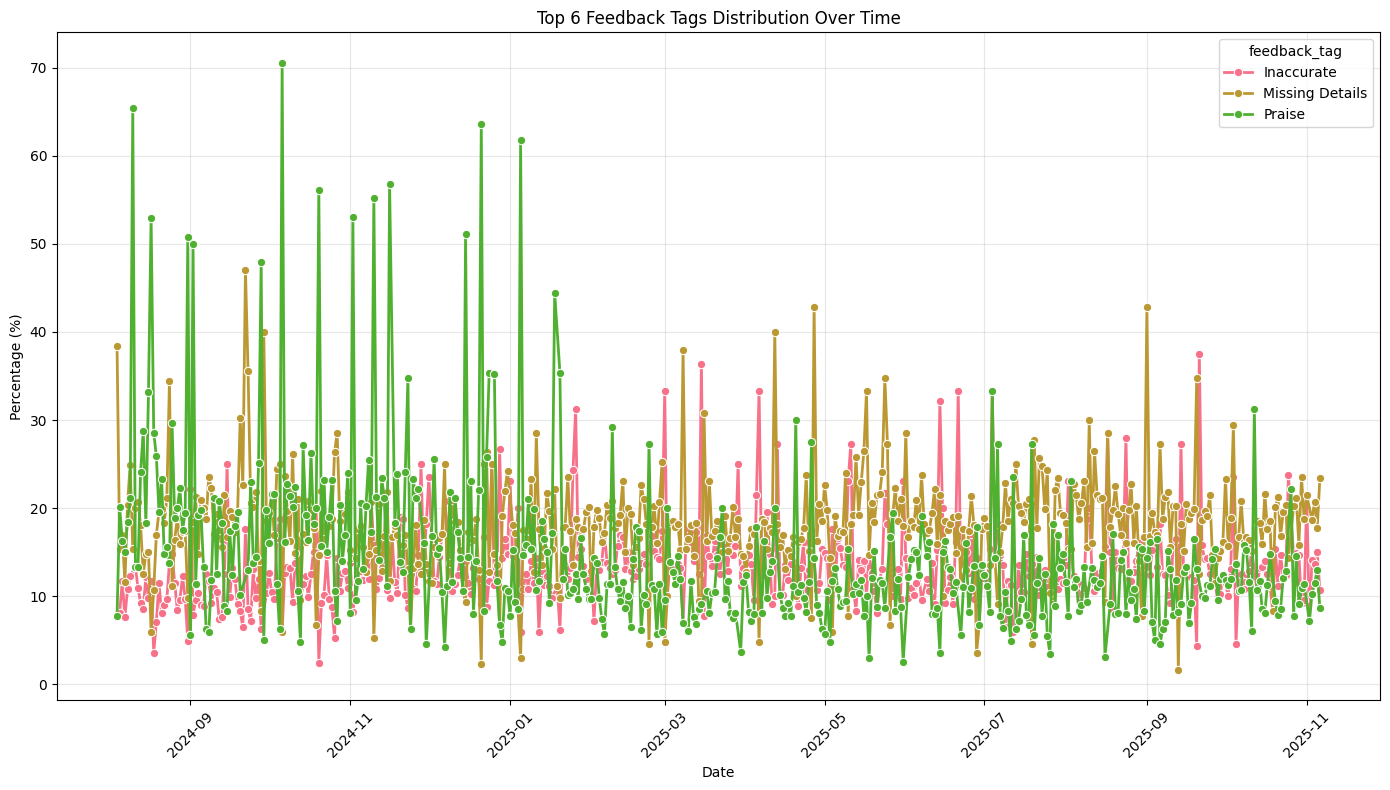

In [34]:
# Group by date and feedback tag, sum encounters
grouped = df.groupby(['note_gen_date', 'feedback_tag'])['num_enc'].sum().reset_index()

# Calculate total encounters per date
date_totals = grouped.groupby('note_gen_date')['num_enc'].sum().reset_index()
date_totals.columns = ['note_gen_date', 'total_enc']

# Merge and calculate percentages
merged = grouped.merge(date_totals, on='note_gen_date')
merged['perc_enc'] = merged['num_enc'] / merged['total_enc'] * 100

# Get top 6 tags and filter data
top_tags = merged.groupby('feedback_tag')['num_enc'].sum().nlargest(3).index
top_merged = merged[merged['feedback_tag'].isin(top_tags)]

# Plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=top_merged, x='note_gen_date', y='perc_enc', 
             hue='feedback_tag', marker='o', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Percentage (%)')
plt.title('Top 6 Feedback Tags Distribution Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
merged.head()

,note_gen_date,feedback_tag,num_enc,total_enc,perc_enc
0,2024-08-04,Grammar Issues,1,13,7.692308
1,2024-08-04,Gratuitous or Irrelevant Information,1,13,7.692308
2,2024-08-04,Inaccurate,1,13,7.692308
3,2024-08-04,Misattribution of Subject,1,13,7.692308
4,2024-08-04,Missing Details,5,13,38.461538


In [9]:
# look at distribution of tags/encounter 
query0= '''select 
  encounter_id,
  count(feedback_tag) as num_fts
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
group by 1'''
ft_df = client.query(query0).to_dataframe()




/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                           encounter_id  num_fts
0  2e3d5445-422f-4328-a2ef-8938107161e3        5
1  70605079-e05a-46a9-b622-5d3a0ce77a6b        6


<Figure size 1200x800 with 0 Axes>

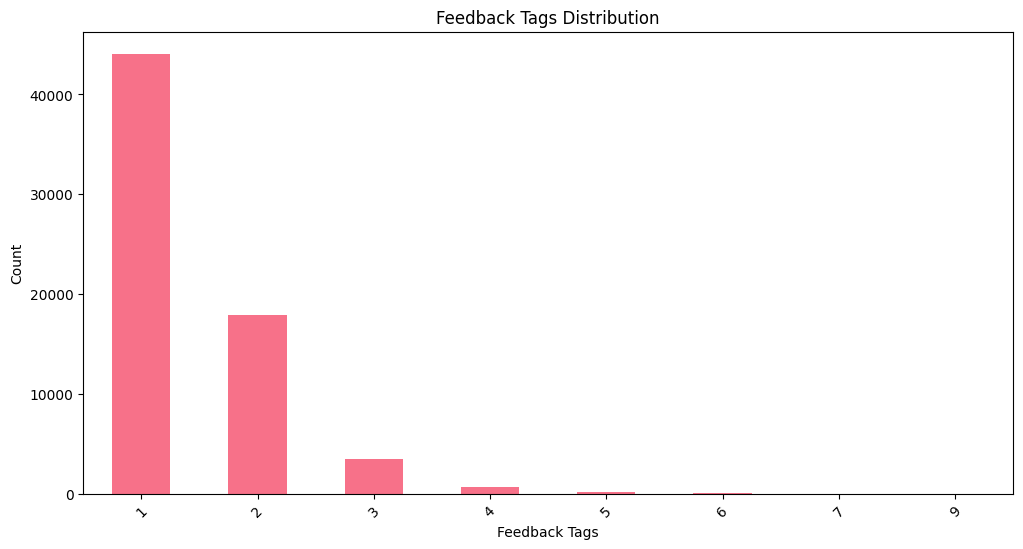

num_fts
1    66.504723
2    27.027068
3     5.170645
4     1.000332
5      0.25046
6     0.042246
7     0.003018
9     0.001509
Name: proportion, dtype: Float64


In [25]:
print(ft_df.head(2))
# Basic histogram/bar chart of feedback tags
plt.figure(figsize=(12, 8))

# Count the frequency of each feedback tag
tag_counts = ft_df['num_fts'].value_counts()

plt.figure(figsize=(12, 6))
ft_df['num_fts'].value_counts().plot(kind='bar')
plt.title('Feedback Tags Distribution')
plt.xlabel('Feedback Tags')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(ft_df['num_fts'].value_counts(normalize=True) * 100)

num_fts
1    66.504723
2    27.027068
3     5.170645
4     1.000332
5      0.25046
6     0.042246
7     0.003018
9     0.001509
Name: proportion, dtype: Float64